<a href="https://colab.research.google.com/github/Sarumathi-G23/Clustering-Algorithm/blob/main/Income_and_Spending_Analysis_using_Hierachical_Clustering(Agglomerative_%26_Divisive_Approach).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage


In [ ]:
d=pd.read_csv("/content/Mall_Customers.csv")

In [ ]:
d.isna().sum()

,0
CustomerID,0
Genre,0
Age,0
Annual_Income_(k$),0
Spending_Score,0


In [ ]:
d.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   CustomerID          200 non-null    int64 
 1   Genre               200 non-null    object
 2   Age                 200 non-null    int64 
 3   Annual_Income_(k$)  200 non-null    int64 
 4   Spending_Score      200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [ ]:
d.shape

(200, 5)

In [ ]:
X = d[['Annual_Income_(k$)', 'Spending_Score']]

In [ ]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
d['Genre']=le.fit_transform(d['Genre'])

In [ ]:
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt
import seaborn as sns

X = d[['Annual_Income_(k$)', 'Spending_Score']]

hc = AgglomerativeClustering(n_clusters=5, metric='euclidean', linkage='ward')
y_hc = hc.fit_predict(X)

d['Cluster'] = y_hc

print("Cluster distribution:")
print(d['Cluster'].value_counts())

Cluster distribution:
Cluster
1    85
2    39
0    32
4    23
3    21
Name: count, dtype: int64


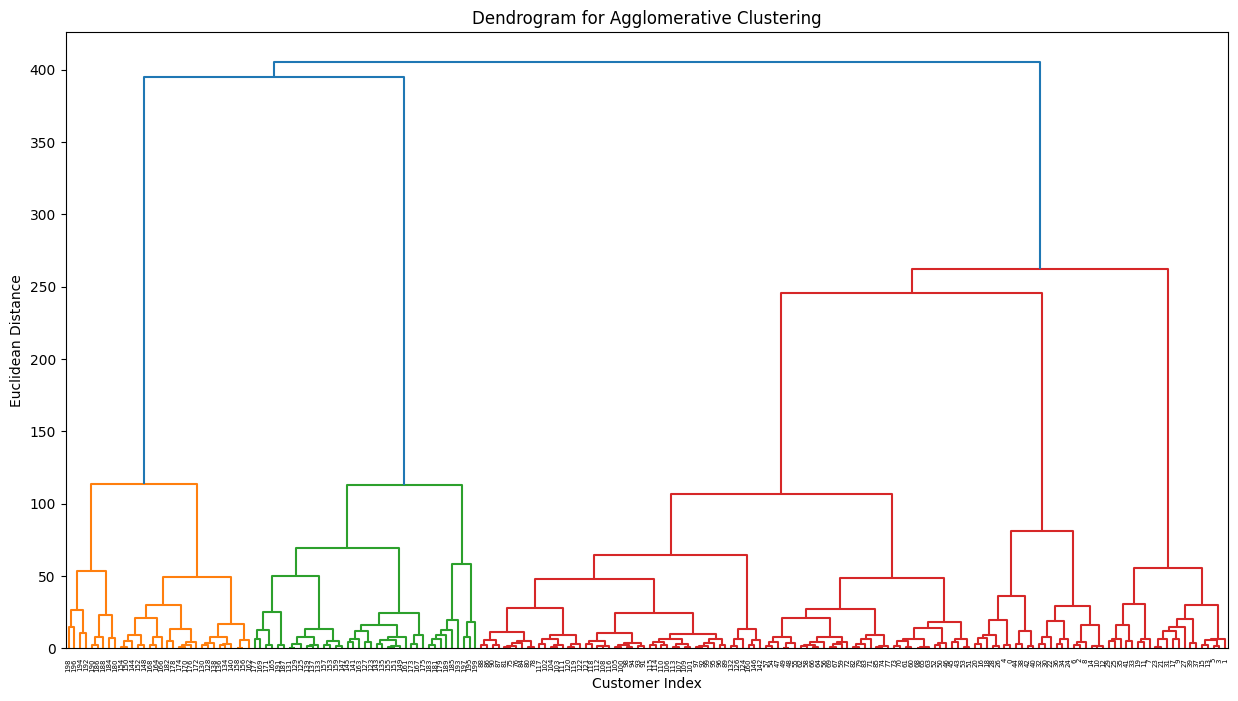

In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

# Generate the linkage matrix
linked = linkage(X, method='ward')

plt.figure(figsize=(15, 8))
dendrogram(linked,
           orientation='top',
           distance_sort='descending',
           show_leaf_counts=True)
plt.title('Dendrogram for Agglomerative Clustering')
plt.xlabel('Customer Index')
plt.ylabel('Euclidean Distance')
plt.show()

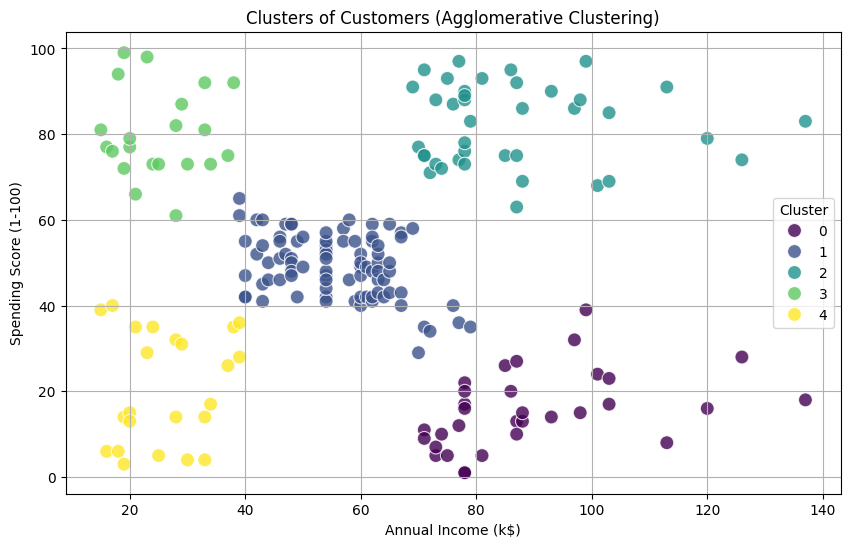

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Annual_Income_(k$)', y='Spending_Score', hue='Cluster', data=d, palette='viridis', s=100, alpha=0.8)
plt.title('Clusters of Customers (Agglomerative Clustering)')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

**DIVISIVE**

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

X = d[['Annual_Income_(k$)', 'Spending_Score']]


kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42, n_init=10)
y_kmeans = kmeans.fit_predict(X)

d['KMeans_Cluster'] = y_kmeans

print("K-Means Cluster distribution:")
print(d['KMeans_Cluster'].value_counts())

K-Means Cluster distribution:
KMeans_Cluster
0    81
1    39
3    35
4    23
2    22
Name: count, dtype: int64


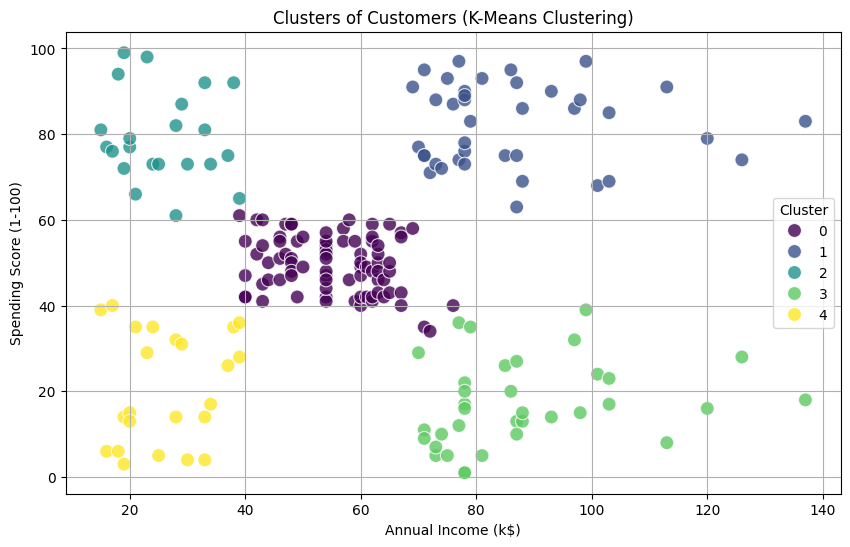

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Annual_Income_(k$)', y='Spending_Score', hue='KMeans_Cluster', data=d, palette='viridis', s=100, alpha=0.8)
plt.title('Clusters of Customers (K-Means Clustering)')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()
